In [ ]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


# **denenecek tüm modeller :**
    
# base_models = {
    'ResNet50': ResNet50,
    'EfficientNetB0': EfficientNetB0,
    'VGG16': VGG16,
    'VGG19': VGG19,
    'InceptionV3': InceptionV3,
    'DenseNet121': DenseNet121,
    'DenseNet169': DenseNet169,
    'DenseNet201': DenseNet201,
    'MobileNetV2': MobileNetV2,
    'NASNetMobile': NASNetMobile
}



In [ ]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50
}

results_file = '/content/drive/My Drive/ssler/training_resultsResNet50.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
94765736/94765736 [==============================] - 1s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5, Epochs: 65
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 60
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5, Epochs: 52
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 84
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 75
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 54
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 53
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.44999998807907104, Epochs: 65
Model: ResNet50, Activation: re

Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
94765736/94765736 [==============================] - 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.4000000059604645, Epochs: 56
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.6000000238418579, Epochs: 58
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 74
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 83
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 64
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 58
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 69
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.6000000238418579,

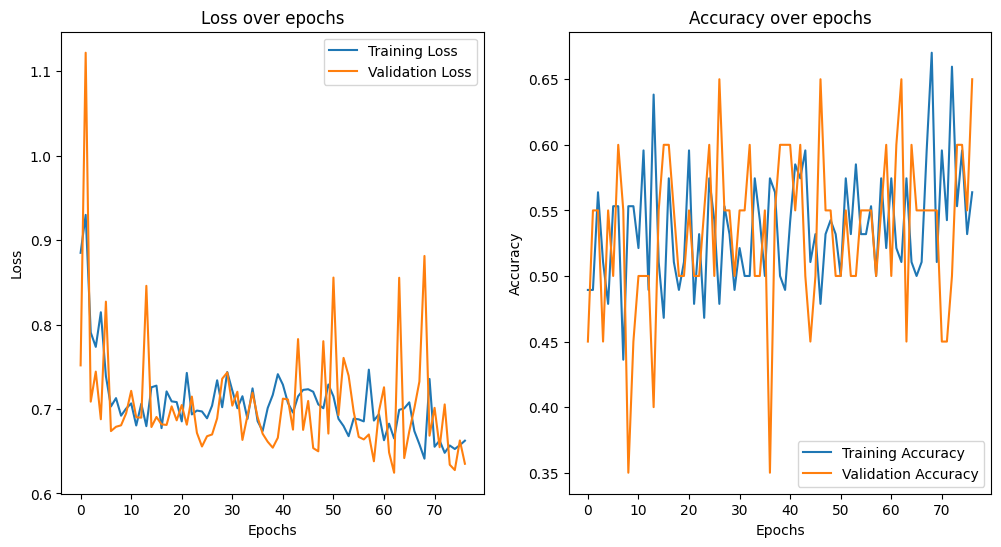

19993432/19993432 [==============================] - 0s 0us/step


ValueError: Layer count mismatch when loading weights from file. Model expected 390 layers, found 108 saved layers.

In [ ]:
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss'
img_height = 224
img_width = 224
batch_size = 4

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet201': DenseNet201
}

results_file = '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

img_height = 224
img_width = 224
batch_size = 4

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50
}

results_file = '/content/drive/My Drive/ssler/training_resultsResNet50v2.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


In [ ]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss'
img_height = 224
img_width = 224
batch_size = 4

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet201': DenseNet201
}

results_file = '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'InceptionV3': InceptionV3
}

results_file = '/content/drive/My Drive/ssler/training_resultsInceptionV3.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
87910968/87910968 [==============================] - 0s 0us/step
Error with model InceptionV3, activation relu, dropout 0.0, learning rate 0.001: Unexpected value for `steps_per_epoch`. Received value is 0. Please check the docstring for `model.fit()` for supported values.
Error with model InceptionV3, activation relu, dropout 0.0, learning rate 0.01: Unexpected value for `steps_per_epoch`. Received value is 0. Please check the docstring for `model.fit()` for supported values.
Error with model InceptionV3, activation relu, dropout 0.0, learning rate 0.1: Unexpected value for `steps_per_epoch`. Received value is 0. Please check the docstring for `model.fit()` for supported values.
Error with model InceptionV3, activation relu, dropout 0.1, learning rate 0.001: Unexpected value for `steps_per_epoch`. Received value is 0. Please check the docstring for `model.fit()` for supported values.
Error with model Incepti

KeyError: 'history'

Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
74836368/74836368 [==============================] - 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Error with model DenseNet201, activation relu, dropout 0.0, learning rate 0.001: [Errno 2] No such file or directory: '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'
Error with model DenseNet201, activation relu, dropout 0.0, learning rate 0.01: [Errno 2] No such file or directory: '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'
Error with model DenseNet201, activation relu, dropout 0.0, learning rate 0.1: [Errno 2] No such file or directory: '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'
Error with model DenseNet201, activation relu, dropout 0.1, learning rate 0.001: [Errno 2] No such file or directory: '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'
Error with model DenseNet201, activation relu, dropout 0.1, learning rate 0.01: [Errno 2] No such file or directory: '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'
Error with model DenseNet201, activation relu, dropout 0.1, learning rate 0.1: [Errno 2] 

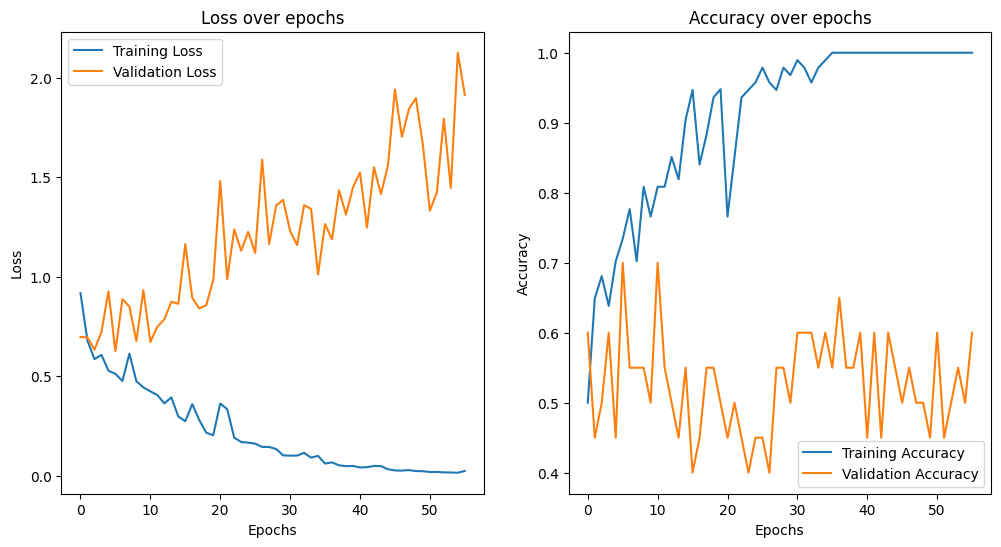

19993432/19993432 [==============================] - 0s 0us/step


ValueError: Layer count mismatch when loading weights from file. Model expected 390 layers, found 403 saved layers.

In [4]:
#veri artırmasız
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss'
img_height = 224
img_width = 224
batch_size = 4

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet201': DenseNet201
}

results_file = '/content/drive/My Drive/ssler/training_resultsDenseNet201.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

img_height = 224
img_width = 224
batch_size = 4

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'InceptionV3': InceptionV3
}

results_file = '/content/drive/My Drive/ssler/training_resultsInceptionV3v2.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
